# P2 - Electricity Load Forecasting (RNNs)
## Deep Learning — Master's Degree in Artificial Intelligence (2025–2026)

**Authors:**
- Patricia Guadalupe Alvarenga Mairena
- Francisco Manuel Vázquez Fernández

## 1. Setup and Imports

We import all necessary libraries and set random seeds for reproducibility.

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

2026-04-23 15:44:02.846379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 15:44:02.857728: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 15:44:02.861323: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 15:44:02.870679: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.17.0


In [3]:
# Get the list of available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Set memory growth to True for all GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth enabled.")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

GPU memory growth enabled.


I0000 00:00:1776959044.205629     533 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776959044.254369     533 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776959044.254411     533 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
%ls

'P2 - RNNs - Electricity Load Forecasting.pdf'
 P2_Electricity_Load_Forecasting.ipynb
 README.md
 download_data_nyiso_practice_rnn.py
 nyiso_hourly_load.csv


---
## 2. Load and Explore Dataset

We load the NYISO hourly electricity load dataset and perform an initial exploration: check shape, columns, data types, missing values, and visualize the total load over time.

In [5]:
# Load the dataset
df = pd.read_csv("nyiso_hourly_load.csv", parse_dates=["Time Stamp"])

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (43656, 13)

Columns: ['Time Stamp', 'CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUD VL', 'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'WEST', 'total_load']

Data types:
Time Stamp    datetime64[ns, UTC]
CAPITL                    float64
CENTRL                    float64
DUNWOD                    float64
GENESE                    float64
HUD VL                    float64
LONGIL                    float64
MHK VL                    float64
MILLWD                    float64
N.Y.C.                    float64
NORTH                     float64
WEST                      float64
total_load                float64
dtype: object

Missing values:
Time Stamp    0
CAPITL        0
CENTRL        0
DUNWOD        0
GENESE        0
HUD VL        0
LONGIL        0
MHK VL        0
MILLWD        0
N.Y.C.        0
NORTH         0
WEST          0
total_load    0
dtype: int64


,Time Stamp,CAPITL,CENTRL,DUNWOD,GENESE,HUD VL,LONGIL,MHK VL,MILLWD,N.Y.C.,NORTH,WEST,total_load
0,2021-01-01 05:00:00+00:00,1229.765829,1652.064229,601.434650,980.770850,1001.962714,2061.066821,841.068829,319.410071,4808.552936,635.814164,1525.174400,15657.085493
1,2021-01-01 06:00:00+00:00,1199.764783,1606.512858,579.089583,934.267075,960.858267,1946.459783,807.607275,307.969050,4631.978808,633.340358,1473.827217,15081.675058
2,2021-01-01 07:00:00+00:00,1172.361075,1578.671450,559.861700,913.383017,936.291717,1855.849567,796.252242,301.264983,4486.644667,617.937925,1435.501408,14654.019750
3,2021-01-01 08:00:00+00:00,1164.461967,1556.862842,548.799792,901.166967,916.932750,1797.270625,794.205750,295.269642,4372.209042,615.713533,1417.398217,14380.291125
4,2021-01-01 09:00:00+00:00,1177.303475,1561.628092,545.171408,898.999517,915.355317,1791.221000,798.552250,295.507442,4336.574433,615.466042,1419.729483,14355.508458


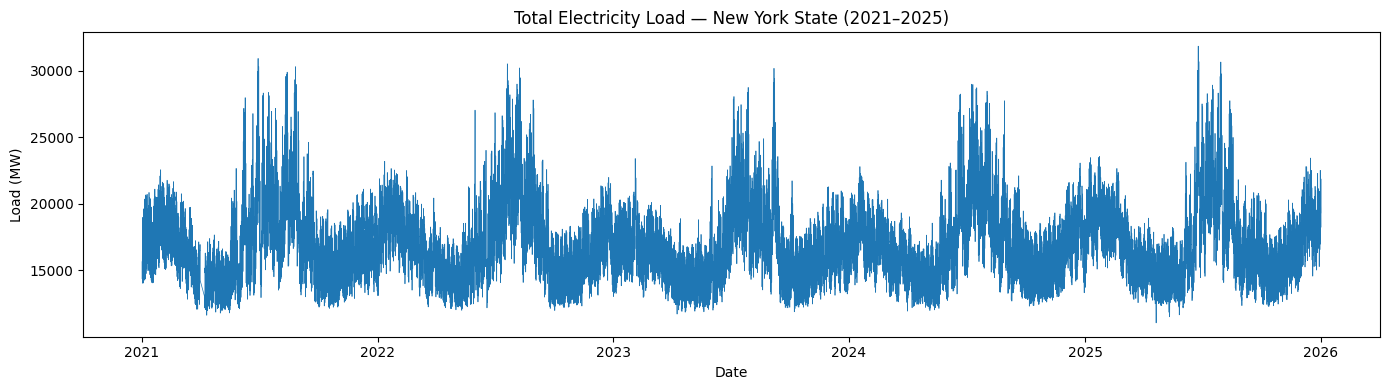

In [6]:
# Visualize total load over time
plt.figure(figsize=(14, 4))
plt.plot(df["Time Stamp"], df["total_load"], linewidth=0.5)
plt.title("Total Electricity Load — New York State (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()

In [7]:
# Basic statistics
df.describe()

,CAPITL,CENTRL,DUNWOD,GENESE,HUD VL,LONGIL,MHK VL,MILLWD,N.Y.C.,NORTH,WEST,total_load
count,43656.000000,43656.000000,43656.000000,43656.000000,43656.000000,43656.000000,43656.000000,43656.000000,43656.000000,43656.000000,43656.000000,43656.000000
mean,1320.679387,1712.259792,651.763726,1079.244693,1059.694855,2272.342230,833.537446,318.074950,5631.808495,637.254827,1703.134578,17219.794980
std,242.984114,285.213967,146.926491,193.826955,242.014957,626.608114,170.365782,77.586636,1150.229840,67.743047,228.888277,3093.991181
min,613.722642,819.032042,241.645808,512.261925,426.670400,1225.844133,287.168450,168.641783,3652.883158,385.670550,1149.166150,11058.275208
25%,1144.660169,1500.302523,552.954947,938.414256,888.098856,1840.286925,707.518952,263.679125,4822.364425,590.213988,1540.379498,15032.269570
50%,1294.250065,1689.508563,625.431015,1055.964179,1023.928508,2129.955108,819.331171,305.497404,5486.479629,629.732588,1680.861608,16756.120346
75%,1468.739977,1904.655725,715.377425,1195.041131,1182.816256,2505.890275,950.704398,359.689387,6162.695555,681.264444,1836.419596,18867.463168
max,2404.433758,2794.872075,1475.823208,2005.080100,2362.059453,5530.543143,1396.822079,684.926493,10833.949107,860.240092,2707.346600,31834.694175


---
## 3. Data Splitting (Train / Validation / Test)

We split the data temporally:
- **Training:** 2021–2023
- **Validation:** 2024
- **Test:** 2025

The `Time Stamp` column is used only for splitting and then discarded from model inputs  (As suggested by the instructions provided). The input features are the 11 zone loads plus the total load (12 features).

In [8]:
# Temporal split
train_df = df[df["Time Stamp"].dt.year <= 2023].copy()
val_df   = df[df["Time Stamp"].dt.year == 2024].copy()
test_df  = df[df["Time Stamp"].dt.year == 2025].copy()

print(f"Train: {train_df.shape}  ({train_df['Time Stamp'].min()} — {train_df['Time Stamp'].max()})")
print(f"Val:   {val_df.shape}  ({val_df['Time Stamp'].min()} — {val_df['Time Stamp'].max()})")
print(f"Test:  {test_df.shape}  ({test_df['Time Stamp'].min()} — {test_df['Time Stamp'].max()})")

# Drop Time Stamp — keep only numeric features
feature_columns = [c for c in df.columns if c != "Time Stamp"]
print(f"\nFeature columns ({len(feature_columns)}): {feature_columns}")

train_data = train_df[feature_columns].values
val_data   = val_df[feature_columns].values
test_data  = test_df[feature_columns].values

Train: (26107, 13)  (2021-01-01 05:00:00+00:00 — 2023-12-31 23:00:00+00:00)
Val:   (8784, 13)  (2024-01-01 00:00:00+00:00 — 2024-12-31 23:00:00+00:00)
Test:  (8760, 13)  (2025-01-01 00:00:00+00:00 — 2025-12-31 23:00:00+00:00)

Feature columns (12): ['CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUD VL', 'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'WEST', 'total_load']


---
## 4. Normalization

We apply z-score normalization using statistics computed **only on the training set**. We store the mean and std of the `total_load` column to be able to denormalize predictions later for reporting MAE in original units (MW).

In [9]:
# Compute normalization statistics from training set
train_mean = train_data.mean(axis=0)
train_std  = train_data.std(axis=0)

# Index of total_load column (last column)
total_load_idx = feature_columns.index("total_load")
total_load_mean = train_mean[total_load_idx]
total_load_std  = train_std[total_load_idx]

print(f"total_load — mean: {total_load_mean:.2f} MW, std: {total_load_std:.2f} MW")

# Apply normalization
train_norm = (train_data - train_mean) / train_std
val_norm   = (val_data   - train_mean) / train_std
test_norm  = (test_data  - train_mean) / train_std

total_load — mean: 17203.48 MW, std: 3085.15 MW


---
## 5. Sequence Generation (Windowing)

We transform the data into supervised learning samples using a sliding window approach.

- **Input:** a window of `SEQ_LEN` consecutive hourly observations (all 12 features).
- **Target:** the `total_load` value `HORIZON` hours after the last observation in the window.

We choose `SEQ_LEN = 48` (2 days of context) and `HORIZON = 3` (predict 3 hours ahead).

**Why 48 hours?** Electricity demand exhibits strong daily periodicity. Using 48 hours provides two full daily cycles, allowing models to capture intra-day patterns (e.g., night vs. peak hours) as well as day-over-day trends. It also comfortably covers the lookback needed for the daily baseline. A longer window (e.g., 168h for weekly patterns) would increase memory and training cost and worsen vanishing gradient issues in SimpleRNN.

We also define a helper function to compute **denormalized MAE** — the evaluation metric required for the practice.

In [10]:
SEQ_LEN = 48   # 48 hours of past observations
HORIZON = 3    # Predict 3 hours ahead

def create_sequences(data, seq_len, horizon, target_idx):
    """
    Create input/output sequences from a 2D array.
    
    Parameters:
        data: np.array of shape (n_timesteps, n_features)
        seq_len: number of past time steps to use as input
        horizon: how many steps ahead to predict
        target_idx: column index of the target variable
    
    Returns:
        X: np.array of shape (n_samples, seq_len, n_features)
        y: np.array of shape (n_samples,)
    """
    X, y = [], []
    for i in range(len(data) - seq_len - horizon + 1):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len + horizon - 1, target_idx])
    return np.array(X), np.array(y)

# Generate sequences
X_train, y_train = create_sequences(train_norm, SEQ_LEN, HORIZON, total_load_idx)
X_val,   y_val   = create_sequences(val_norm,   SEQ_LEN, HORIZON, total_load_idx)
X_test,  y_test  = create_sequences(test_norm,  SEQ_LEN, HORIZON, total_load_idx)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (26057, 48, 12), y_train: (26057,)
X_val:   (8734, 48, 12),   y_val:   (8734,)
X_test:  (8710, 48, 12),  y_test:  (8710,)


In [11]:
def denormalized_mae(y_true_norm, y_pred_norm, mean, std):
    """Compute MAE in original scale (MW)."""
    y_true = y_true_norm * std + mean
    y_pred = y_pred_norm * std + mean
    return np.mean(np.abs(y_true - y_pred))

# Dictionary to store results for final comparison
results = {}

---
# Part 1: Baselines

## 6. Baseline 1 - Last Value

The simplest baseline: predict the total load 3 hours ahead using the **last observed total load** value in the input window. This is equivalent to assuming the load stays constant.

In [12]:
# Last-value baseline: use the last total_load in the window as the prediction
y_pred_last = X_test[:, -1, total_load_idx]

mae_last = denormalized_mae(y_test, y_pred_last, total_load_mean, total_load_std)
results["Last Value"] = mae_last
print(f"Last-Value Baseline — Denormalized MAE: {mae_last:.2f} MW")

Last-Value Baseline — Denormalized MAE: 1399.99 MW


## 7. Baseline 2 - Daily (Same Hour Previous Day)

We predict using the total load from **24 hours before the target time**. Since the target is 3 hours after the end of the window, we look back `24 - 3 = 21` steps from the end of the window (i.e., position `-21` in the sequence).

This baseline captures the daily seasonality of electricity demand.

In [13]:
# Daily baseline: value from the same hour one day earlier
# Target is at position (end_of_window + HORIZON), i.e., 3 hours after the last step.
# Same hour previous day = 24h before the target = window[-1] - 24 + HORIZON = window[-(24 - HORIZON + 1)]
# Since HORIZON=3: position is -(24 - 3) = -21 from the end, i.e., index SEQ_LEN - 21

offset = 24 - HORIZON  # 21 steps back from end of window
y_pred_daily = X_test[:, -offset, total_load_idx]

mae_daily = denormalized_mae(y_test, y_pred_daily, total_load_mean, total_load_std)
results["Daily"] = mae_daily
print(f"Daily Baseline — Denormalized MAE: {mae_daily:.2f} MW")

Daily Baseline — Denormalized MAE: 1116.23 MW


## 8. Neural Baseline - Conv1D + Dense

We build a neural baseline combining **1D convolutional layers** (to extract local temporal patterns) with **Dense layers**. This serves as a non-recurrent neural reference point for comparison with the RNN models.

In [14]:
# Common training hyperparameters (shared across all neural models)
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3

def plot_training_history(history, title=""):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(8, 3))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title(f"Training Curves — {title}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a Keras model and store denormalized MAE."""
    y_pred = model.predict(X_test, verbose=0).flatten()
    mae = denormalized_mae(y_test, y_pred, total_load_mean, total_load_std)
    results[model_name] = mae
    print(f"{model_name} — Denormalized MAE: {mae:.2f} MW")
    return mae

In [15]:
# Neural baseline: Conv1D + Dense
n_features = X_train.shape[2]

model_cnn = keras.Sequential([
    layers.Conv1D(filters=32, kernel_size=3, activation="relu",
                  input_shape=(SEQ_LEN, n_features)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
], name="CNN_Baseline")

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

model_cnn.summary()

Model: "CNN_Baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 46, 32)            1184      
                                                                 
 conv1d_1 (Conv1D)           (None, 44, 32)            3104      
                                                                 
 max_pooling1d (MaxPooling1  (None, 22, 32)            0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 704)               0         
                                                                 
 dense (Dense)               (None, 64)                45120     
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                      

I0000 00:00:1776959045.574055     533 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776959045.574110     533 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776959045.574123     533 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776959045.816638     533 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776959045.816692     533 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-23

In [16]:
# Train CNN baseline
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


2026-04-23 15:44:06.772444: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1776959046.846349     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959046.858102     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959046.858303     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959046.861371     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959046.861750     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959046.862130     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959046.871293     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959046.871734     625 gpu_

  1/408 [..............................] - ETA: 10:20 - loss: 0.9567

W0000 00:00:1776959047.484910     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959047.486596     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959047.487200     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959047.487409     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959047.489040     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959047.489854     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959047.490027     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959047.490253     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959047.490941     624 gp

 38/408 [=>............................] - ETA: 2s - loss: 0.2250

...

408/408 [==============================] - 2s 5ms/step - loss: 0.0203 - val_loss: 0.0294
Epoch 5/50
408/408 [==============================] - ETA: 0s - loss: 0.0180

W0000 00:00:1776959057.644186     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959057.644521     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959057.644622     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959057.644710     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959057.644797     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959057.644892     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959057.645077     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959057.645211     625 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959057.645349     625 gp

408/408 [==============================] - 2s 4ms/step - loss: 0.0180 - val_loss: 0.0245
Epoch 6/50
408/408 [==============================] - ETA: 0s - loss: 0.0164

W0000 00:00:1776959166.601403     621 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959166.601533     621 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959166.601653     621 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959166.601733     621 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959166.601813     621 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959166.601916     621 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959166.602076     621 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959166.602177     621 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959166.602304     621 gp

408/408 [==============================] - 2s 5ms/step - loss: 0.0164 - val_loss: 0.0294
Epoch 7/50
408/408 [==============================] - 2s 4ms/step - loss: 0.0151 - val_loss: 0.0313
Epoch 8/50
408/408 [==============================] - 2s 5ms/step - loss: 0.0142 - val_loss: 0.0231
Epoch 9/50
408/408 [==============================] - 2s 5ms/step - loss: 0.0139 - val_loss: 0.0235
Epoch 10/50
408/408 [==============================] - 2s 5ms/step - loss: 0.0123 - val_loss: 0.0222
Epoch 11/50
408/408 [==============================] - 2s 5ms/step - loss: 0.0117 - val_loss: 0.0237
Epoch 12/50
408/408 [==============================] - 2s 4ms/step - loss: 0.0117 - val_loss: 0.0223
Epoch 13/50
408/408 [==============================] - 2s 5ms/step - loss: 0.0112 - val_loss: 0.0209
Epoch 14/50
408/408 [==============================] - 2s 5ms/step - loss: 0.0105 - val_loss: 0.0248
Epoch 15/50
408/408 [==============================] - 2s 4ms/step - loss: 0.0102 - val_loss: 0.0212
Epoch

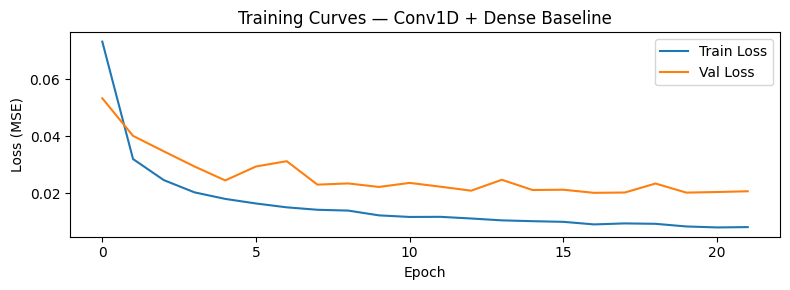

W0000 00:00:1776959089.849082     620 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.849582     620 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.849700     620 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.849839     620 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.850006     620 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.850155     620 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.850335     620 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.850504     620 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.850661     620 gp

Conv1D + Dense — Denormalized MAE: 413.36 MW


W0000 00:00:1776959089.935274     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.935593     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.935692     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.935794     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.935893     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.935992     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.936251     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.936446     624 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776959089.936586     624 gp

413.3648270789125

In [17]:
plot_training_history(history_cnn, "Conv1D + Dense Baseline")
evaluate_model(model_cnn, X_test, y_test, "Conv1D + Dense")

---
# Part 2: Recurrent Models

Each model uses only one type of recurrent layer, combined with non-recurrent layers where appropriate:

| Model | Recurrent layers | Non-recurrent layers |
|---|---|---|
| SimpleRNN v1 | `SimpleRNN(64)` | `Dense(1)` |
| SimpleRNN v2 | `SimpleRNN(64)` + `SimpleRNN(32)` | `Dropout`, `Dense` |
| LSTM v1 | `LSTM(64)` | `Dense(1)` |
| LSTM v2 | `LSTM(64)` + `LSTM(32)` | `Dropout`, `Dense` |
| GRU v1 | `GRU(64)` | `Dense(1)` |
| GRU v2 | `GRU(64)` + `GRU(32)` | `Dropout`, `Dense` |

**Experimental design:** For each recurrent architecture we explore two meaningful configurations: a single-layer baseline (64 units) and a deeper variant (2 stacked layers with dropout 0.2). **We call them v1 and v2**. This covers the key design choices (number of units, layers, and regularization) without exhaustive hyperparameter search. All models share the same training setup: Adam optimizer (lr=1e-3), batch size 64, up to 50 epochs with EarlyStopping (patience=5). The final model selection for each architecture is justified based on test MAE and convergence behavior.

## 9. SimpleRNN Model

We build a model using `SimpleRNN` layers. We will experiment with:
- Number of units (e.g., 32, 64)
- Number of stacked RNN layers (1 vs 2)
- Dropout for regularization

We keep the same optimizer (Adam), learning rate, batch size and early stopping strategy as the CNN baseline for fair comparison.

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  4/408 [..............................] - ETA: 18s - loss: 1.4422

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


408/408 [==============================] - 18s 41ms/step - loss: 0.0975 - val_loss: 0.0421
Epoch 2/50
408/408 [==============================] - 17s 41ms/step - loss: 0.0288 - val_loss: 0.0339
Epoch 3/50
408/408 [==============================] - 18s 44ms/step - loss: 0.0238 - val_loss: 0.0293
Epoch 4/50
408/408 [==============================] - 21s 51ms/step - loss: 0.0217 - val_loss: 0.0284
Epoch 5/50
408/408 [==============================] - 34s 83ms/step - loss: 0.0204 - val_loss: 0.0293
Epoch 6/50
408/408 [==============================] - 23s 55ms/step - loss: 0.0194 - val_loss: 0.0265
Epoch 7/50
408/408 [==============================] - 23s 57ms/step - loss: 0.0186 - val_loss: 0.0275
Epoch 8/50
408/408 [==============================] - 22s 54ms/step - loss: 0.0183 - val_loss: 0.0265
Epoch 9/50
408/408 [==============================] - 22s 54ms/step - loss: 0.0176 - val_loss: 0.0309
Epoch 10/50
408/408 [==============================] - 22s 53ms/step - loss: 0.0172 - val_los

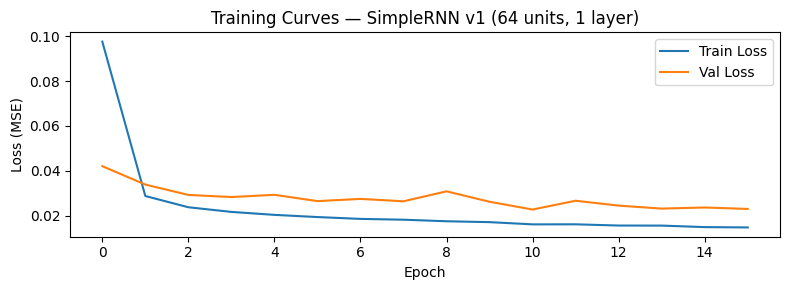

SimpleRNN v1 — Denormalized MAE: 446.43 MW


446.4325740831515

In [18]:
# --- Experiment 1: SimpleRNN with 1 layer, 64 units ---
model_srnn_v1 = keras.Sequential([
    layers.SimpleRNN(64, input_shape=(SEQ_LEN, n_features)),
    layers.Dense(1)
], name="SimpleRNN_v1")

model_srnn_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

history_srnn_v1 = model_srnn_v1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

plot_training_history(history_srnn_v1, "SimpleRNN v1 (64 units, 1 layer)")
evaluate_model(model_srnn_v1, X_test, y_test, "SimpleRNN v1")

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/408 [..............................] - ETA: 7:55 - loss: 1.2065

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


408/408 [==============================] - 64s 154ms/step - loss: 0.2077 - val_loss: 0.0668
Epoch 2/50
408/408 [==============================] - 72s 176ms/step - loss: 0.0837 - val_loss: 0.0522
Epoch 3/50
408/408 [==============================] - 67s 165ms/step - loss: 0.0673 - val_loss: 0.0391
Epoch 4/50
408/408 [==============================] - 56s 138ms/step - loss: 0.0600 - val_loss: 0.0358
Epoch 5/50
408/408 [==============================] - 60s 148ms/step - loss: 0.0548 - val_loss: 0.0396
Epoch 6/50
408/408 [==============================] - 71s 174ms/step - loss: 0.0503 - val_loss: 0.0308
Epoch 7/50
408/408 [==============================] - 58s 142ms/step - loss: 0.0480 - val_loss: 0.0343
Epoch 8/50
408/408 [==============================] - 55s 134ms/step - loss: 0.0459 - val_loss: 0.0275
Epoch 9/50
408/408 [==============================] - 71s 173ms/step - loss: 0.0450 - val_loss: 0.0444
Epoch 10/50
408/408 [==============================] - 80s 196ms/step - loss: 0.0436

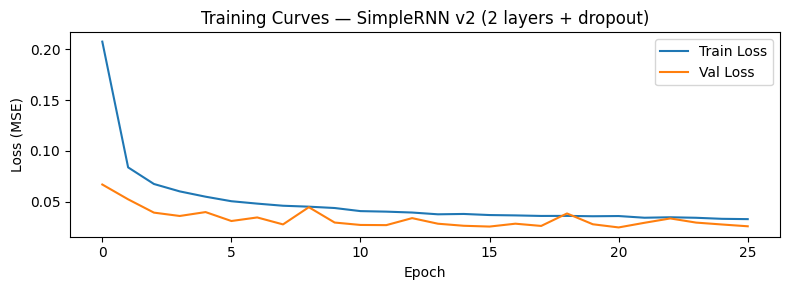

SimpleRNN v2 — Denormalized MAE: 459.91 MW


459.91392223661813

In [20]:
# --- Experiment 2: SimpleRNN with 2 stacked layers + dropout ---
model_srnn_v2 = keras.Sequential([
    layers.SimpleRNN(64, return_sequences=True, input_shape=(SEQ_LEN, n_features)),
    layers.Dropout(0.2),
    layers.SimpleRNN(32),
    layers.Dropout(0.2),
    layers.Dense(1)
], name="SimpleRNN_v2")

model_srnn_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

history_srnn_v2 = model_srnn_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

plot_training_history(history_srnn_v2, "SimpleRNN v2 (2 layers + dropout)")
evaluate_model(model_srnn_v2, X_test, y_test, "SimpleRNN v2")

**SimpleRNN — Discussion:**

**v1 (1 layer, 64 units)** achieves a test MAE of ~446 MW, while **v2 (2 stacked layers + dropout)** performs worse at ~460 MW. The single-layer model converges faster (~15 epochs vs ~25) and reaches a lower validation loss (~0.02 vs ~0.03).

**Why does v2 underperform?** Stacking SimpleRNN layers deepens the computational graph, which amplifies the **vanishing gradient problem** — the very weakness SimpleRNN is known for. At each time step, gradients are multiplied by the recurrent weight matrix; over 48 steps this already causes significant gradient decay. Adding a second layer doubles the depth of the unrolled network, making it even harder for gradients to propagate back to early time steps. Additionally, dropout (0.2) further reduces the effective signal during training without a compensating benefit, since the task does not appear to require strong regularization (no overfitting is observed in v1).

**Vanishing gradient impact:** With `SEQ_LEN = 48`, the SimpleRNN must backpropagate through 48 multiplications of the recurrent kernel. The tanh activation saturates gradients, causing the model to effectively "forget" information from the earlier part of the window. This limits SimpleRNN's ability to fully exploit the 48-hour context compared to gated architectures (LSTM/GRU).

Selected final model: **SimpleRNN v1**: simpler architecture, faster convergence, and better generalization.

---
## 10. LSTM Model

We build a model using `LSTM` layers. LSTMs address the vanishing gradient problem through gating mechanisms, which should help with our 48-step input sequences. We explore similar design choices as with the SimpleRNN.

Epoch 1/50
  1/408 [..............................] - ETA: 28:30 - loss: 1.2639

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

408/408 [==============================] - 31s 66ms/step - loss: 0.1233 - val_loss: 0.0456
Epoch 2/50
408/408 [==============================] - 26s 65ms/step - loss: 0.0289 - val_loss: 0.0382
Epoch 3/50
408/408 [==============================] - 26s 63ms/step - loss: 0.0233 - val_loss: 0.0314
Epoch 4/50
408/408 [==============================] - 32s 78ms/step - loss: 0.0202 - val_loss: 0.0273
Epoch 5/50
408/408 [==============================] - 32s 77ms/step - loss: 0.0179 - val_loss: 0.0251
Epoch 6/50
408/408 [==============================] - 31s 76ms/step - loss: 0.0164 - val_loss: 0.0263
Epoch 7/50
408/408 [==============================] - 28s 68ms/step - loss: 0.0153 - val_loss: 0.0240
Epoch 8/50
408/408 [==============================] - 41s 100ms/step - loss: 0.0145 - val_loss: 0.0255
Epoch 9/50
408/408 [==============================] - 28s 68ms/step - loss: 0.0142 - val_loss: 0.0212
Epoch 10/50
408/408 [==============================] - 27s 66ms/step - loss: 0.0133 - val_lo

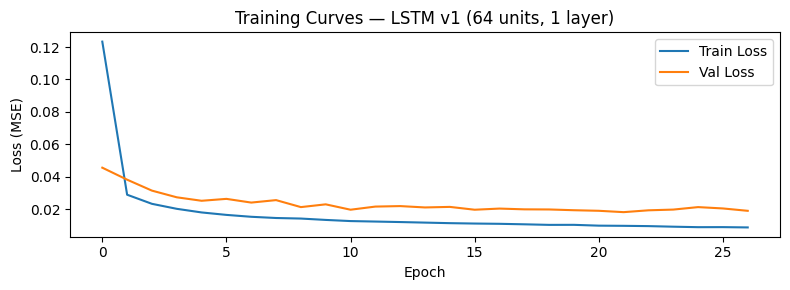

LSTM v1 — Denormalized MAE: 404.50 MW


404.50339555299524

In [22]:
# --- Experiment 1: LSTM with 1 layer, 64 units ---
model_lstm_v1 = keras.Sequential([
    layers.LSTM(64, input_shape=(SEQ_LEN, n_features), unroll=True),
    layers.Dense(1)
], name="LSTM_v1")

model_lstm_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

history_lstm_v1 = model_lstm_v1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

plot_training_history(history_lstm_v1, "LSTM v1 (64 units, 1 layer)")
evaluate_model(model_lstm_v1, X_test, y_test, "LSTM v1")

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/408 [..............................] - ETA: 1:09:15 - loss: 1.1638

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


408/408 [==============================] - 70s 148ms/step - loss: 0.1798 - val_loss: 0.0703
Epoch 2/50
408/408 [==============================] - 58s 142ms/step - loss: 0.0704 - val_loss: 0.0629
Epoch 3/50
408/408 [==============================] - 65s 158ms/step - loss: 0.0567 - val_loss: 0.0493
Epoch 4/50
408/408 [==============================] - 60s 148ms/step - loss: 0.0488 - val_loss: 0.0415
Epoch 5/50
408/408 [==============================] - 58s 142ms/step - loss: 0.0438 - val_loss: 0.0402
Epoch 6/50
408/408 [==============================] - 62s 152ms/step - loss: 0.0410 - val_loss: 0.0359
Epoch 7/50
408/408 [==============================] - 58s 143ms/step - loss: 0.0389 - val_loss: 0.0327
Epoch 8/50
408/408 [==============================] - 64s 157ms/step - loss: 0.0367 - val_loss: 0.0313
Epoch 9/50
408/408 [==============================] - 58s 142ms/step - loss: 0.0343 - val_loss: 0.0285
Epoch 10/50
408/408 [==============================] - 55s 135ms/step - loss: 0.0331

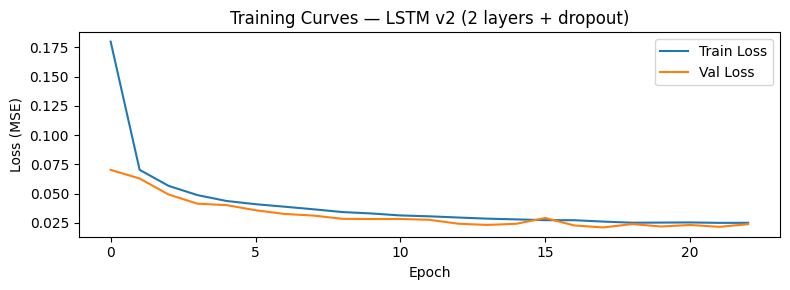

LSTM v2 — Denormalized MAE: 452.42 MW


452.4244545662637

In [23]:
# --- Experiment 2: LSTM with 2 stacked layers + dropout ---
model_lstm_v2 = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, n_features), unroll=True),
    layers.Dropout(0.2),
    layers.LSTM(32, unroll=True),
    layers.Dropout(0.2),
    layers.Dense(1)
], name="LSTM_v2")

model_lstm_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

history_lstm_v2 = model_lstm_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

plot_training_history(history_lstm_v2, "LSTM v2 (2 layers + dropout)")
evaluate_model(model_lstm_v2, X_test, y_test, "LSTM v2")

**LSTM — Discussion:**

**v1 (1 layer, 64 units)** achieves the best overall MAE of ~405 MW, while **v2 (2 stacked layers + dropout)** reaches only ~452 MW, a significant 47 MW gap. LSTM v1 also converges smoothly over ~27 epochs with val_loss ~0.02, whereas v2 settles at a higher val_loss (~0.025) in ~22 epochs.

**How LSTM handles long-term dependencies vs SimpleRNN:** The key advantage of LSTM is its **cell state**, a highway for information that flows across time steps with only linear transformations (element-wise addition). The forget, input, and output gates control what information is retained or discarded at each step. This means gradients can flow through the cell state without repeated multiplication by the recurrent weight matrix, effectively mitigating the vanishing gradient problem. The result is clear: LSTM v1 (405 MW) substantially outperforms SimpleRNN v1 (446 MW), a ~9% improvement, confirming that the gating mechanism enables better exploitation of the full 48-hour context window.

**Why does v2 underperform v1?** Unlike SimpleRNN where stacking worsens vanishing gradients, in LSTM the degradation comes from a different source: **overfitting and optimization difficulty**. The stacked LSTM v2 has significantly more parameters (two LSTM layers: 64 + 32 units), and the dropout layers discard learned representations during training. Since LSTM v1 already shows no overfitting (train and val loss converge tightly), the dropout is unnecessary regularization that only hurts learning capacity. The added depth also makes the optimization landscape more complex without providing additional representational benefit for this relatively straightforward forecasting task.

**Training time trade-off:** LSTM layers are computationally expensive due to the three gates (4× the parameters of SimpleRNN per unit). Using `unroll=True` trades memory for speed but still results in longer per-epoch training compared to SimpleRNN. However, the ~9% MAE improvement over SimpleRNN justifies this cost. The gating mechanism provides genuine value for 48-step sequences.

Selected final model: **LSTM v1**: best absolute performance across all models, smooth convergence, and no need for additional regularization.

---
## 11. GRU Model

We build a model using `GRU` layers. GRUs are similar to LSTMs but with a simpler gating mechanism (2 gates instead of 3), which often results in faster training while achieving comparable performance.

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  1/408 [..............................] - ETA: 55:31 - loss: 1.4569

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


408/408 [==============================] - -68s -186685us/step - loss: 0.1307 - val_loss: 0.0515
Epoch 2/50
408/408 [==============================] - 31s 76ms/step - loss: 0.0375 - val_loss: 0.0403
Epoch 3/50
408/408 [==============================] - 30s 73ms/step - loss: 0.0275 - val_loss: 0.0351
Epoch 4/50
408/408 [==============================] - 31s 75ms/step - loss: 0.0222 - val_loss: 0.0281
Epoch 5/50
408/408 [==============================] - 36s 89ms/step - loss: 0.0194 - val_loss: 0.0261
Epoch 6/50
408/408 [==============================] - 34s 84ms/step - loss: 0.0179 - val_loss: 0.0249
Epoch 7/50
408/408 [==============================] - 33s 81ms/step - loss: 0.0169 - val_loss: 0.0238
Epoch 8/50
408/408 [==============================] - 34s 84ms/step - loss: 0.0158 - val_loss: 0.0243
Epoch 9/50
408/408 [==============================] - 35s 85ms/step - loss: 0.0151 - val_loss: 0.0203
Epoch 10/50
408/408 [==============================] - 38s 93ms/step - loss: 0.0143 - v

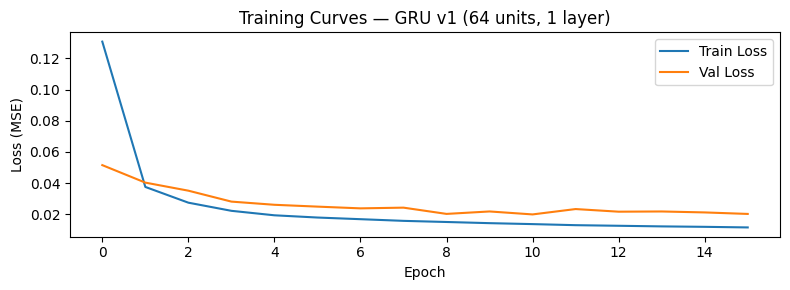

GRU v1 — Denormalized MAE: 416.94 MW


416.9365383499894

In [25]:
# --- Experiment 1: GRU with 1 layer, 64 units ---
model_gru_v1 = keras.Sequential([
    layers.GRU(64, input_shape=(SEQ_LEN, n_features), unroll=True),
    layers.Dense(1)
], name="GRU_v1")

model_gru_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

history_gru_v1 = model_gru_v1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

plot_training_history(history_gru_v1, "GRU v1 (64 units, 1 layer)")
evaluate_model(model_gru_v1, X_test, y_test, "GRU v1")

Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/408 [..............................] - ETA: 1:38:41 - loss: 1.1730

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


408/408 [==============================] - 89s 183ms/step - loss: 0.1625 - val_loss: 0.0528
Epoch 2/50
408/408 [==============================] - 74s 182ms/step - loss: 0.0626 - val_loss: 0.0443
Epoch 3/50
408/408 [==============================] - 94s 230ms/step - loss: 0.0492 - val_loss: 0.0359
Epoch 4/50
408/408 [==============================] - 105s 258ms/step - loss: 0.0446 - val_loss: 0.0329
Epoch 5/50
408/408 [==============================] - 68s 168ms/step - loss: 0.0409 - val_loss: 0.0311
Epoch 6/50
408/408 [==============================] - 71s 174ms/step - loss: 0.0381 - val_loss: 0.0299
Epoch 7/50
408/408 [==============================] - 83s 204ms/step - loss: 0.0370 - val_loss: 0.0285
Epoch 8/50
408/408 [==============================] - 92s 225ms/step - loss: 0.0348 - val_loss: 0.0337
Epoch 9/50
408/408 [==============================] - 97s 237ms/step - loss: 0.0334 - val_loss: 0.0223
Epoch 10/50
408/408 [==============================] - 157s 386ms/step - loss: 0.03

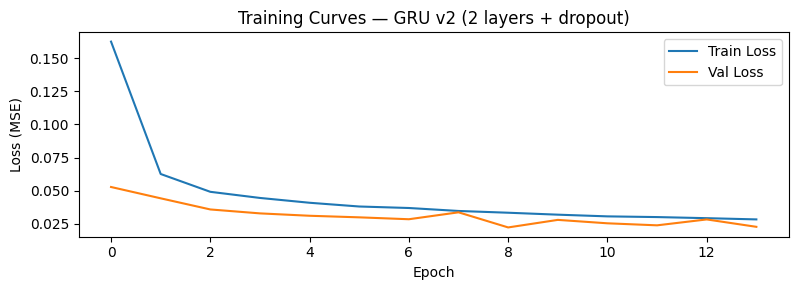

GRU v2 — Denormalized MAE: 439.61 MW


439.6109725528089

In [26]:
# --- Experiment 2: GRU with 2 stacked layers + dropout ---
model_gru_v2 = keras.Sequential([
    layers.GRU(64, return_sequences=True, input_shape=(SEQ_LEN, n_features), unroll=True),
    layers.Dropout(0.2),
    layers.GRU(32, unroll=True),
    layers.Dropout(0.2),
    layers.Dense(1)
], name="GRU_v2")

model_gru_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

history_gru_v2 = model_gru_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

plot_training_history(history_gru_v2, "GRU v2 (2 layers + dropout)")
evaluate_model(model_gru_v2, X_test, y_test, "GRU v2")

**GRU — Discussion:**

**v1 (1 layer, 64 units)** achieves ~417 MW, while **v2 (2 stacked layers + dropout)** scores ~440 MW. GRU v1 converges quickly (~15 epochs, val_loss ~0.02) with clean training curves, whereas v2 settles at a higher val_loss (~0.025) in ~13 epochs. Once again, the single-layer variant generalizes better.

**GRU vs LSTM trade-offs:** GRU uses 2 gates (reset and update) instead of LSTM's 3 (forget, input, output), resulting in ~25% fewer parameters per unit. This translates to faster per-epoch training and quicker convergence (15 epochs vs 27 for LSTM v1). However, LSTM v1 (405 MW) still edges out GRU v1 (417 MW) by ~3%. The simpler gating of GRU is sufficient to solve the vanishing gradient problem. GRU v1 (417 MW) strongly outperforms SimpleRNN v1 (446 MW), but the additional expressiveness of LSTM's separate cell state provides a slight advantage on this task.

**Why does v2 underperform?** The pattern is consistent across all three architectures: the task is simple enough that a single layer with 64 units provides sufficient capacity. Stacking layers adds optimization complexity and dropout removes useful signal without preventing overfitting (which is not present in v1). GRU v2's early stopping triggers at epoch ~13, suggesting the model struggles to improve rather than benefiting from extended training.

**Practical consideration:** If training time or computational budget were a constraint, GRU v1 would be the preferred choice: it offers near-LSTM performance (only 12 MW worse) with noticeably faster training. For this practice, we select v1 as the best GRU configuration.

Selected final model: **GRU v1**: fast convergence, strong performance, and efficient parameter usage.

---
## 12. Results Comparison and Final Analysis

We summarize the denormalized MAE (MW) on the test set for all models and provide a comparative analysis.

In [27]:
# Summary table
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Denormalized MAE (MW)"]
).sort_values("Denormalized MAE (MW)")

print("=" * 50)
print("FINAL RESULTS — Test Set (Denormalized MAE in MW)")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)

FINAL RESULTS — Test Set (Denormalized MAE in MW)
         Model  Denormalized MAE (MW)
       LSTM v1             404.503396
Conv1D + Dense             413.364827
        GRU v1             416.936538
        GRU v2             439.610973
  SimpleRNN v1             446.432574
       LSTM v2             452.424455
  SimpleRNN v2             459.913922
         Daily            1116.228092
    Last Value            1399.987086


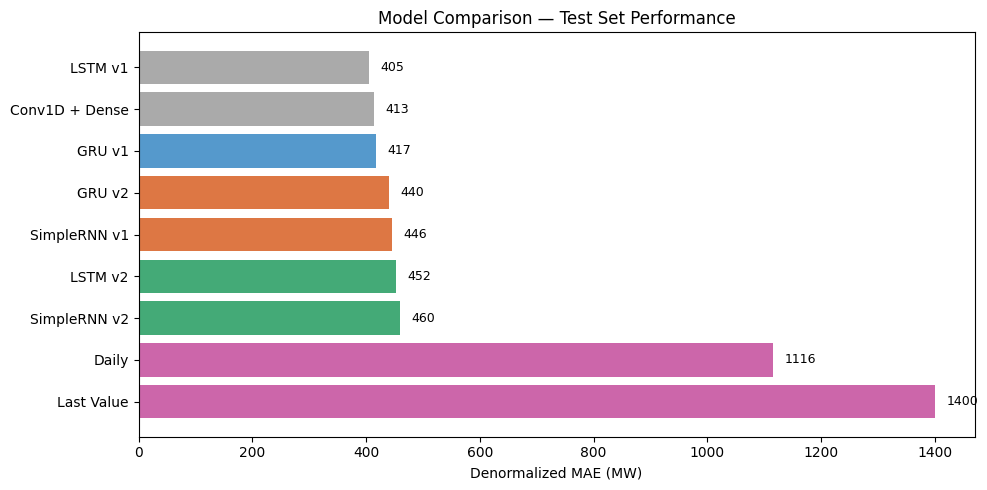

In [28]:
# Bar chart comparison
plt.figure(figsize=(10, 5))
colors = ["#aaaaaa", "#aaaaaa", "#5599cc", "#dd7744", "#dd7744", "#44aa77", "#44aa77", "#cc66aa", "#cc66aa"]
bars = plt.barh(results_df["Model"], results_df["Denormalized MAE (MW)"],
                color=colors[:len(results_df)])
plt.xlabel("Denormalized MAE (MW)")
plt.title("Model Comparison — Test Set Performance")
plt.gca().invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height() / 2,
             f"{width:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Final Discussion

**1. Baselines vs Neural models:**

All neural models significantly outperform the simple baselines. The best model (LSTM v1, ~405 MW) reduces MAE by ~64% compared to Last Value (~1400 MW) and by ~64% compared to Daily (~1116 MW). Even the worst neural model (SimpleRNN v2, ~460 MW) is still 2.4x better than the Daily baseline.

**2. Recurrent vs Non-recurrent:**

The Conv1D + Dense baseline achieves ~413 MW, which is surprisingly competitive, placing 2nd overall. Only LSTM v1 (~405 MW) beats it, and by a slim ~2% margin. GRU v1 (~417 MW) is essentially tied with it. This suggests that for a 3-hour-ahead prediction, local temporal patterns captured by convolutions are almost as informative as full sequential memory. The recurrent models do provide a small edge, but the benefit of sequential modeling is modest for this particular horizon.

**3. SimpleRNN vs LSTM vs GRU:**

- **Best MAE:** LSTM v1 (~405 MW), followed by Conv1D (~413 MW), then GRU v1 (~417 MW), then SimpleRNN v1 (~446 MW).
- **Training speed:** GRU v1 converges fastest (~15 epochs), SimpleRNN v1 also ~15 epochs, while LSTM v1 takes ~27 epochs. GRU gives the best speed-to-performance ratio.
- **Stacking + dropout:** It hurt performance in all cases. v2 variants consistently scored worse than v1 (SimpleRNN: +14 MW, LSTM: +47 MW, GRU: +23 MW). The single-layer models showed no overfitting, so the added regularization was unnecessary and the extra depth made optimization harder.

**4. Effect of dropout:**

Dropout was harmful in every case. All v2 models (which included Dropout 0.2) performed worse than their v1 counterparts. Since the v1 models already showed tight train/val loss convergence with no signs of overfitting, dropout only removed useful information during training without providing any regularization benefit. For this dataset and task complexity, the models are not prone to overfitting with 64 units and early stopping already in place.

**5. Daily baseline relevance:**

The Daily baseline (~1116 MW) is much better than Last Value (~1400 MW), confirming the strong 24-hour periodicity in electricity demand. However, it is still far from neural model performance (2.7x worse than LSTM v1). The neural models can capture more complex patterns beyond simple daily repetition.

**5. Limitations and future work:**

- We did not include time-based features (hour of day, day of week) which could improve performance, especially for capturing weekly patterns.
- Only two configurations per architecture were tested. A broader search over units, layers, and learning rates could yield better results.
- Attention mechanisms or Transformer-based models could be explored to see if they outperform the recurrent approaches.
- The slim margin between Conv1D and LSTM suggests that hybrid architectures (e.g., Conv1D + LSTM) might combine the best of both worlds.